In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,f1_score

In [2]:
df = pd.read_csv(r'/kaggle/input/datasets/aliabdelmenam/hand-land-mark-gestures/hand_landmarks_data.csv')

In [3]:
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# MediaPipe hand connections
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),          # Thumb
    (0,5),(5,6),(6,7),(7,8),          # Index
    (0,9),(9,10),(10,11),(11,12),     # Middle
    (0,13),(13,14),(14,15),(15,16),   # Ring
    (0,17),(17,18),(18,19),(19,20),   # Pinky
    (5,9),(9,13),(13,17),             # Palm
]

CONNECTION_COLORS = (
    ["#FF6B6B"]*4 +   # Thumb
    ["#FFD93D"]*4 +   # Index
    ["#6BCB77"]*4 +   # Middle
    ["#4D96FF"]*4 +   # Ring
    ["#C77DFF"]*4 +   # Pinky
    ["#AAAAAA"]*3     # Palm
)

def plot_hand_landmarks(landmarks, mode="2d", title="Hand Landmarks", figsize=(6, 6)):
    """
    Plot MediaPipe hand landmarks from a flat (63,) array.

    Parameters
    ----------
    landmarks : array-like, shape (63,) or (21, 3)
        Flat vector [x0,y0,z0, x1,y1,z1, ..., x20,y20,z20]
        or already shaped (21, 3).
    mode : '2d' or '3d'
    """
    pts = np.array(landmarks).reshape(21, 3)   
    x, y, z = pts[:, 0], pts[:, 1], pts[:, 2]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor("#1a1a2e")
    fig.patch.set_facecolor("#1a1a2e")

    for (i, j), color in zip(HAND_CONNECTIONS, CONNECTION_COLORS):
        ax.plot([x[i],x[j]], [y[i],y[j]],
                color=color, linewidth=2.5, solid_capstyle="round")

    ax.scatter(x, y, c="white", edgecolors="black", s=80, zorder=5, linewidths=1.5)

    for idx in range(21):
        ax.annotate(str(idx), (x[idx], y[idx]),
                    fontsize=7, ha="center", va="center",
                    color="black", fontweight="bold")

    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    plt.title(title, color="white" if mode == "2d" else "black", pad=10)
    plt.tight_layout()
    plt.show()

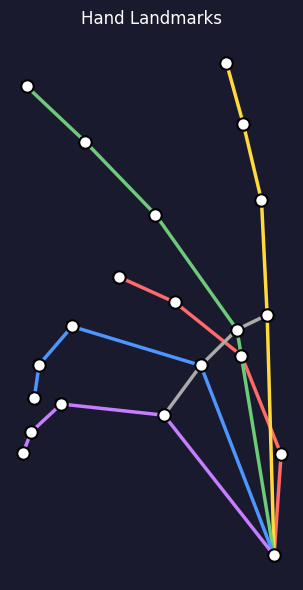

In [5]:
landmarks_array = df.iloc[15000][:-1].values.reshape(-1,1)  
plot_hand_landmarks(landmarks_array, mode="2d")

## NULLS & Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

x1       0
y1       0
z1       0
x2       0
y2       0
        ..
z20      0
x21      0
y21      0
z21      0
label    0
Length: 64, dtype: int64

## Scaling

removing from each hand wrist point (0), and normalize by mid finger tip (13)

In [8]:
import numpy as np
import pandas as pd

def normalize_hand(row):
    # wrist (landmark 0)
    x0, y0 = row["x1"], row["y1"]

    # middle finger tip (landmark 13)
    xm, ym = row["x13"], row["y13"]
    
    new_row = row.copy()
    for i in range(1, 22):
        new_row[f"x{i}"] = (row[f"x{i}"] - x0) / xm
        new_row[f"y{i}"] = (row[f"y{i}"] - y0) / ym

    return new_row

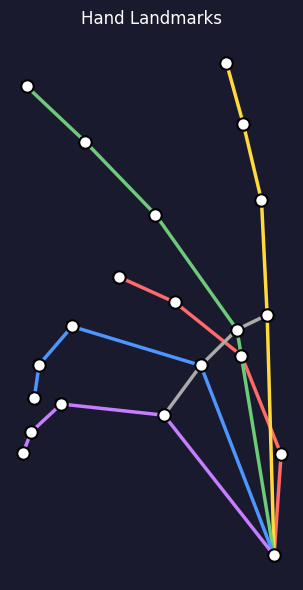

In [9]:
landmarks_array = df.iloc[15000][:-1].values.reshape(-1,1)  
plot_hand_landmarks(landmarks_array, mode="2d")

In [10]:
df['label'].value_counts()

label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64

In [11]:
df['label'].nunique()

18

## Spliting

In [12]:
X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## Encoding

In [13]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

X_train = X_train.apply(normalize_hand, axis=1)
X_test = X_test.apply(normalize_hand, axis=1)


# Models

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier



NUM_CLASSES = 18

models = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'criterion': ['gini', 'log_loss','entropy'],
            'max_depth': [8, 12, 18, 30, 50],
        }
    },
    
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [150, 300, 600, 1000],
            'max_depth': [12, 20, 35],
        }
    },
    
    
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=5000, n_jobs=-1),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'l1_ratio': [0.2, 0.5, 0.8],  # only for elasticnet
        }
    },
    
    'KNN': {
        'model': KNeighborsClassifier(n_jobs=-1),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11, 15],
            'weights': ['uniform', 'distance'],
        }
    },
    
    'SVM': {
        'model': SVC(random_state=42),
        'params': {
            'C': [0.1, 1, 10,100,120,150,170],
            'kernel': ['rbf'],
        }
    },
}

print(f"{len(models)} models configured")

5 models configured


In [15]:
from sklearn.model_selection import StratifiedKFold
import json
from datetime import datetime

tuned_models = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# results dictionary
results = {}

for name, model_info in models.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(model_info['model'], model_info['params'], cv=cv, scoring='f1_macro', n_jobs=-1, verbose=5)
    grid_search.fit(X_train, y_train)

    # Store in the main dictionary
    tuned_models[name] = {
        'best_estimator': grid_search.best_estimator_,
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_
    }

    # Create a serializable version for JSON
    results[name] = {
        'best_score': float(grid_search.best_score_),  # Convert numpy float to Python float
        'best_params': grid_search.best_params_,
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    # Save to JSON file after each model
    with open('best_hyperparameters.json', 'w') as f:
        json.dump(results, f, indent=4)

    print(f"Finished tuning {name}. Best score: {grid_search.best_score_:.4f}")
    print(f"Best params saved to best_hyperparameters.json\n")

print("All models tuned successfully.")

Tuning Decision Tree...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Finished tuning Decision Tree. Best score: 0.8552
Best params saved to best_hyperparameters.json

Tuning Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV 1/3] END .......criterion=gini, max_depth=8;, score=0.666 total time=   2.0s
[CV 3/3] END ......criterion=gini, max_depth=12;, score=0.815 total time=   2.4s
[CV 3/3] END ......criterion=gini, max_depth=18;, score=0.850 total time=   2.8s
[CV 2/3] END ......criterion=gini, max_depth=50;, score=0.847 total time=   2.8s
[CV 3/3] END ...criterion=log_loss, max_depth=8;, score=0.763 total time=   4.4s
[CV 3/3] END ..criterion=log_loss, max_depth=12;, score=0.841 total time=   5.0s
[CV 1/3] END ..criterion=log_loss, max_depth=30;, score=0.848 total time=   5.2s
[CV 2/3] END ..criterion=log_loss, max_depth=50;, score=0.859 total time=   5.2s
[CV 3/3] END ....criterion=entropy, max_depth=8;, score=0.763 total time=   4.4s
[CV

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 2/3] END .......criterion=gini, max_depth=8;, score=0.665 total time=   2.0s
[CV 2/3] END ......criterion=gini, max_depth=12;, score=0.812 total time=   2.4s
[CV 1/3] END ......criterion=gini, max_depth=30;, score=0.855 total time=   2.7s
[CV 1/3] END ......criterion=gini, max_depth=50;, score=0.855 total time=   2.7s
[CV 2/3] END ...criterion=log_loss, max_depth=8;, score=0.765 total time=   4.5s
[CV 1/3] END ..criterion=log_loss, max_depth=18;, score=0.851 total time=   5.2s
[CV 2/3] END ..criterion=log_loss, max_depth=30;, score=0.859 total time=   5.4s
[CV 3/3] END ..criterion=log_loss, max_depth=50;, score=0.858 total time=   5.2s
[CV 1/3] END ...criterion=entropy, max_depth=12;, score=0.836 total time=   5.1s
[CV 2/3] END ...criterion=entropy, max_depth=18;, score=0.859 total time=   5.3s
[CV 3/3] END ...criterion=entropy, max_depth=30;, score=0.858 total time=   5.2s
[CV 1/3] END ....max_depth=12, n_estimators=150;, score=0.891 total time=  27.7s
[CV 2/3] END ....max_depth=1

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

Finished tuning Logistic Regression. Best score: 0.9041
Best params saved to best_hyperparameters.json

Tuning KNN...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Finished tuning KNN. Best score: 0.9026
Best params saved to best_hyperparameters.json

Tuning SVM...
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Finished tuning SVM. Best score: 0.9606
Best params saved to best_hyperparameters.json

All models tuned successfully.


In [16]:
print('best_estimator', grid_search.best_estimator_)
print('best_score', grid_search.best_score_)
print('best_params', grid_search.best_params_)

best_estimator SVC(C=170, random_state=42)
best_score 0.9606196369481331
best_params {'C': 170, 'kernel': 'rbf'}


# so now this is the model that we will choose <br> SVM {'kernel':'rbf', C:150}